In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
from eval.shared_setup import *

Loading pre-computed retrieval results...
  ✓ approximation: 50,575 rows
  ✓ bm25: 50,575 rows
✓ Boundaries loaded (UW: 1.0000…175763168.0000)

Computing metrics and assigning decile columns...

Loading expected document lengths from corpus...
  Matched 44,857 / 44,857 question IDs

✓ shared_setup complete — 2 strategies ready
  Collection : wiki_full_bil
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
  Strategies : ['approximation', 'bm25']
  Decile mode: chunk_weighted


---

## TF-IDF Distribution Per Decile

Investigates how **term richness** and **vocabulary specificity** vary across popularity deciles.

| Panel | Metric | What it tells us |
|---|---|---|
| A | Mean unique terms / doc | Vocabulary breadth — do popular articles use more distinct terms? |
| B | Mean TF-IDF score (non-zero entries) | Keyword intensity — how "keyword-dense" are docs? |
| C | Mean IDF of used terms | Term specificity — do rare or common words dominate each decile? |

> **Heavy computation is sampled.** We draw up to `TFIDF_SAMPLE_PER_DECILE` docs per decile via reservoir sampling,
> fit a `TfidfVectorizer`, compute summary stats, and **cache the results** in `metadata.json`.
> Subsequent runs load instantly.

✓ Loaded TF-IDF stats from metadata.json [chunk (size=1000, overlap=100) level, cached v2]

 Decile  src_docs  n_chunks  mean_unique_terms   mean_tfidf   mean_idf  vocab_cov
      1       20000      29858               45.6       0.1235     4.9625     0.7710
      2       20000      48933               60.2       0.1109     5.1222     0.9151
      3       20000      64345               63.7       0.1083     5.1418     0.9543
      4       20000      76660               66.3       0.1066     5.1446     0.9710
      5       20000      97091               67.7       0.1058     5.1916     0.9843
      6       20000     117448               68.9       0.1050     5.1862     0.9897
      7       20000     150993               69.8       0.1043     5.1843     0.9937
      8       20000     196200               70.6       0.1038     5.1875     0.9962
      9       20000     282637               71.6       0.1032     5.1867     0.9974
     10       20000     495927               72.6       0.102

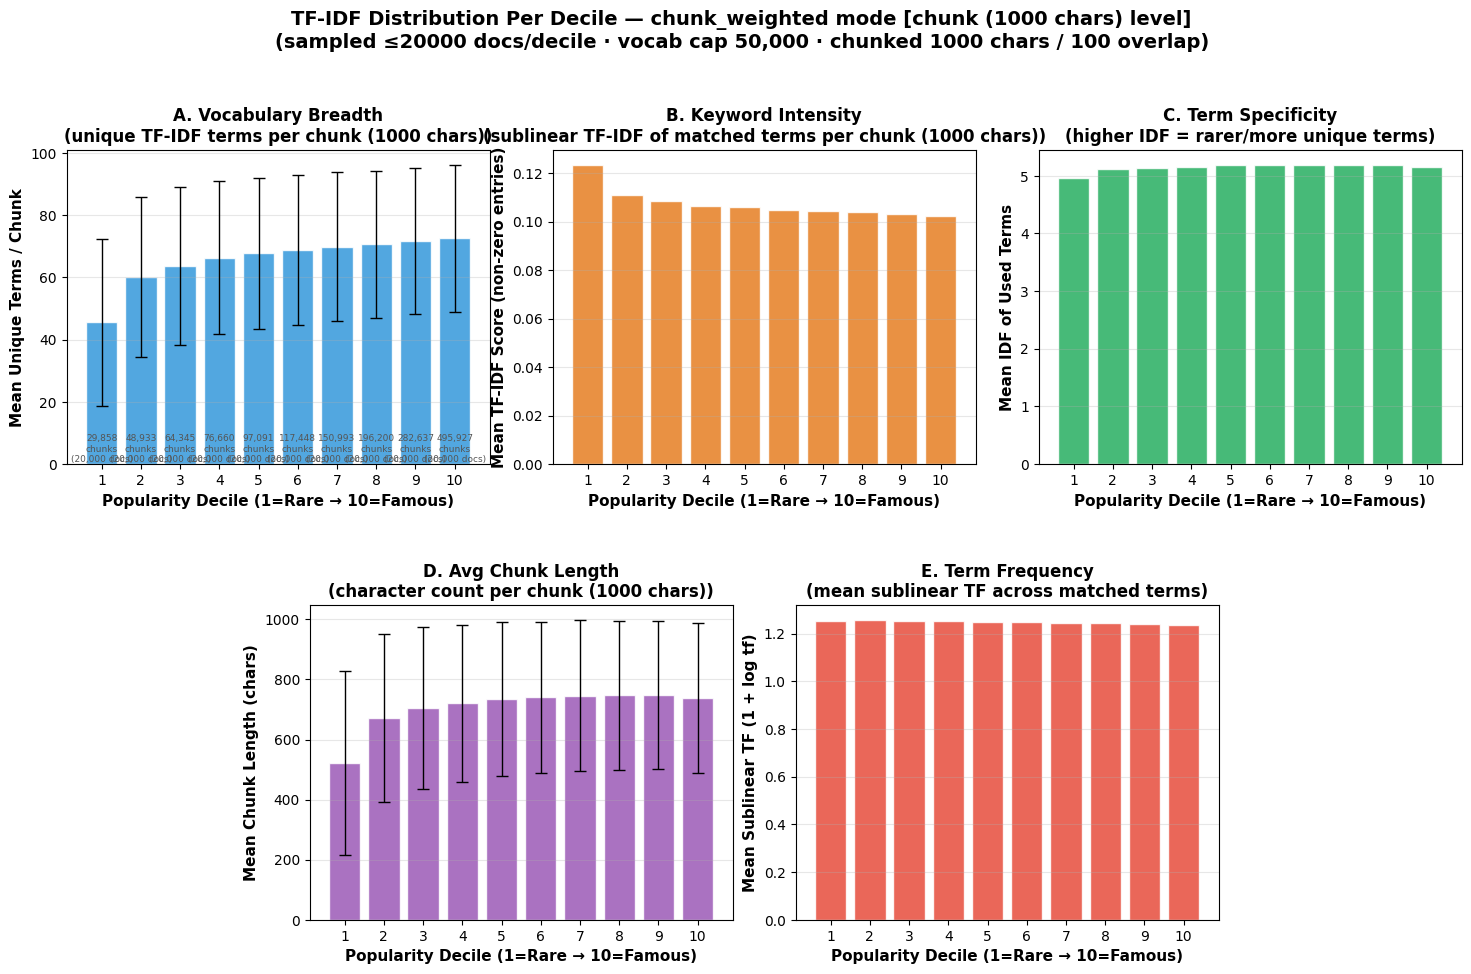

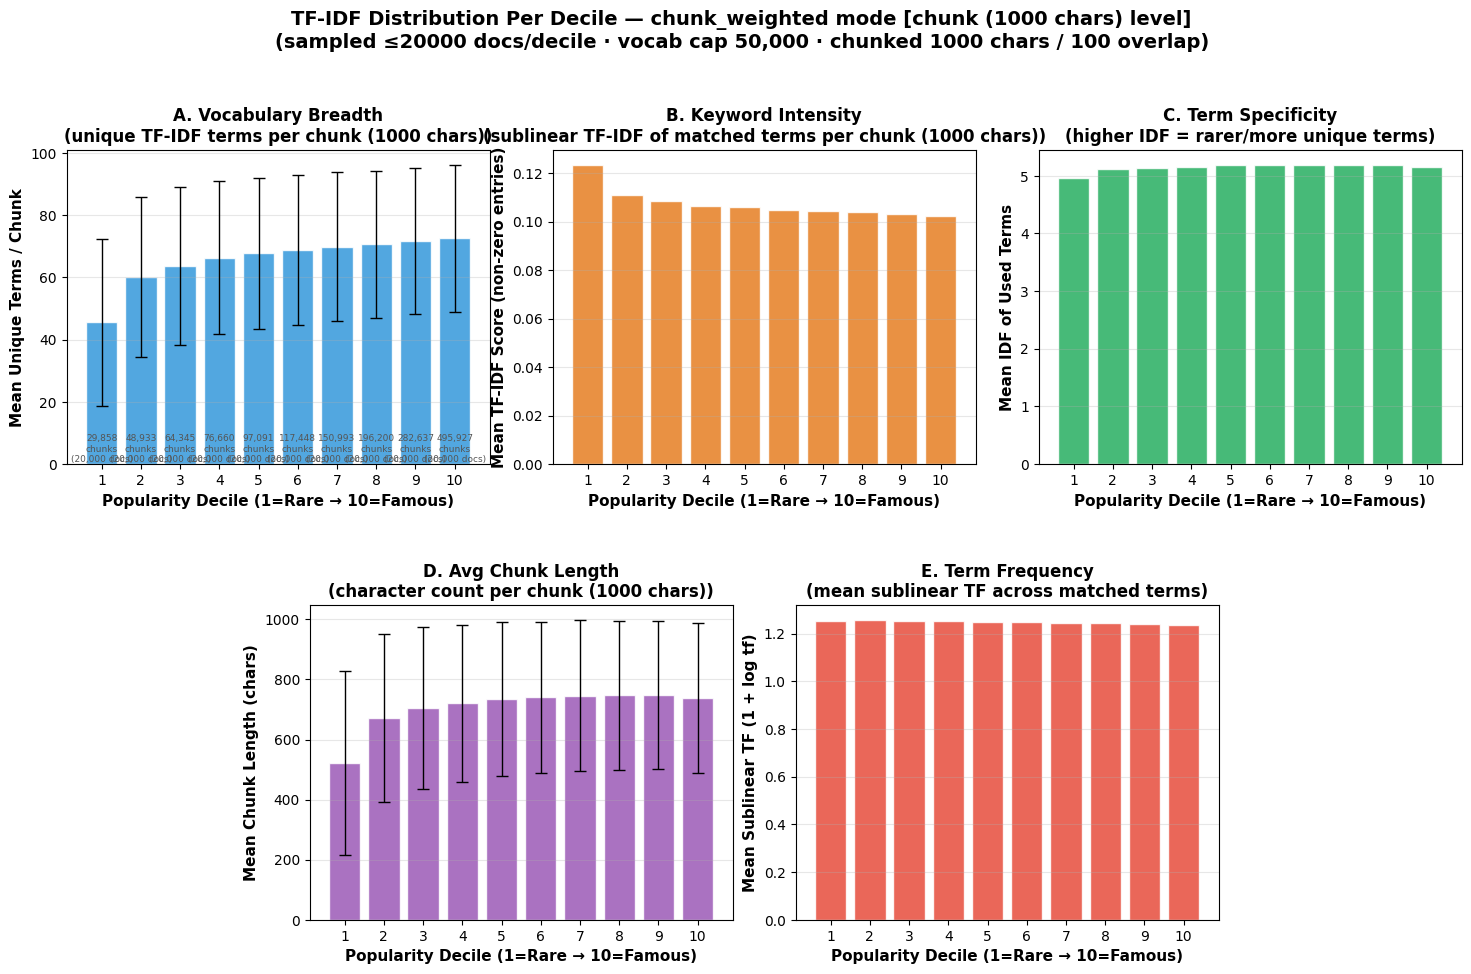

In [2]:
from src.metrics.tfidf_service import (
    load_or_compute_tfidf_stats,
    print_tfidf_stats,
    plot_tfidf_stats,
)
from src.metrics.decile_utils import boundaries_for

TFIDF_SAMPLE_PER_DECILE = 20_000    # docs per decile  (increase for accuracy; ~5-15 s at 300)
TFIDF_MAX_FEATURES      = 50_000  # vocabulary cap for the vectorizer

boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)

tfidf_stats = load_or_compute_tfidf_stats(
    metadata_path=metadata_path,
    corpus_path=CORPUS_PATH,
    boundaries=boundaries,
    sample_per_decile=TFIDF_SAMPLE_PER_DECILE,
    max_features=TFIDF_MAX_FEATURES,
    chunk_size=1000,
    chunk_overlap=100,
)

print_tfidf_stats(tfidf_stats)

plot_tfidf_stats(
    tfidf_stats,
    decile_mode=DECILE_MODE,
    sample_per_decile=TFIDF_SAMPLE_PER_DECILE,
    max_features=TFIDF_MAX_FEATURES,
    out_path=RESULTS_DIR / "tfidf_distribution_per_decile.png",
    chunk_overlap=100,
    chunk_size=1000,
)

### 9b. TF-IDF, IDF & Avg Chunk Length per Decile — Per Dataset

Breaks down the corpus-level TF-IDF metrics (TF, IDF, chunk length) by **dataset/company**.
Because `tfidf_stats` is corpus-wide (not per-dataset), this view uses the *query distribution* within each dataset to
show how many queries each dataset contributes per decile (annotated counts), while the bar height
always reflects the **same corpus-level metric** for that decile.  The target document length
(`doc_length`) from `results_by_strategy` — which *is* per-query — is shown as a second
overlay curve.

One figure is generated per strategy.  Rows = datasets, columns = (TF | IDF | avg chunk length).
Saved as `tfidf_idf_chunk_per_dataset_{strategy}.png`.

Loading corpus-wide TF-IDF vectorizer…
✓ Loading corpus vectorizer from cache: tfidf_vectorizer_decile_tfidf_stats_chunks_1000_100_n20000.pkl

Computing per-dataset TF-IDF stats for: APPROXIMATION
  Fetching 44,857 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 44,857 / 44,857 IDs in corpus
  Transforming 721,907 texts with corpus vectorizer (vocab=50,000)…
  Vocabulary in use: 50,000 terms


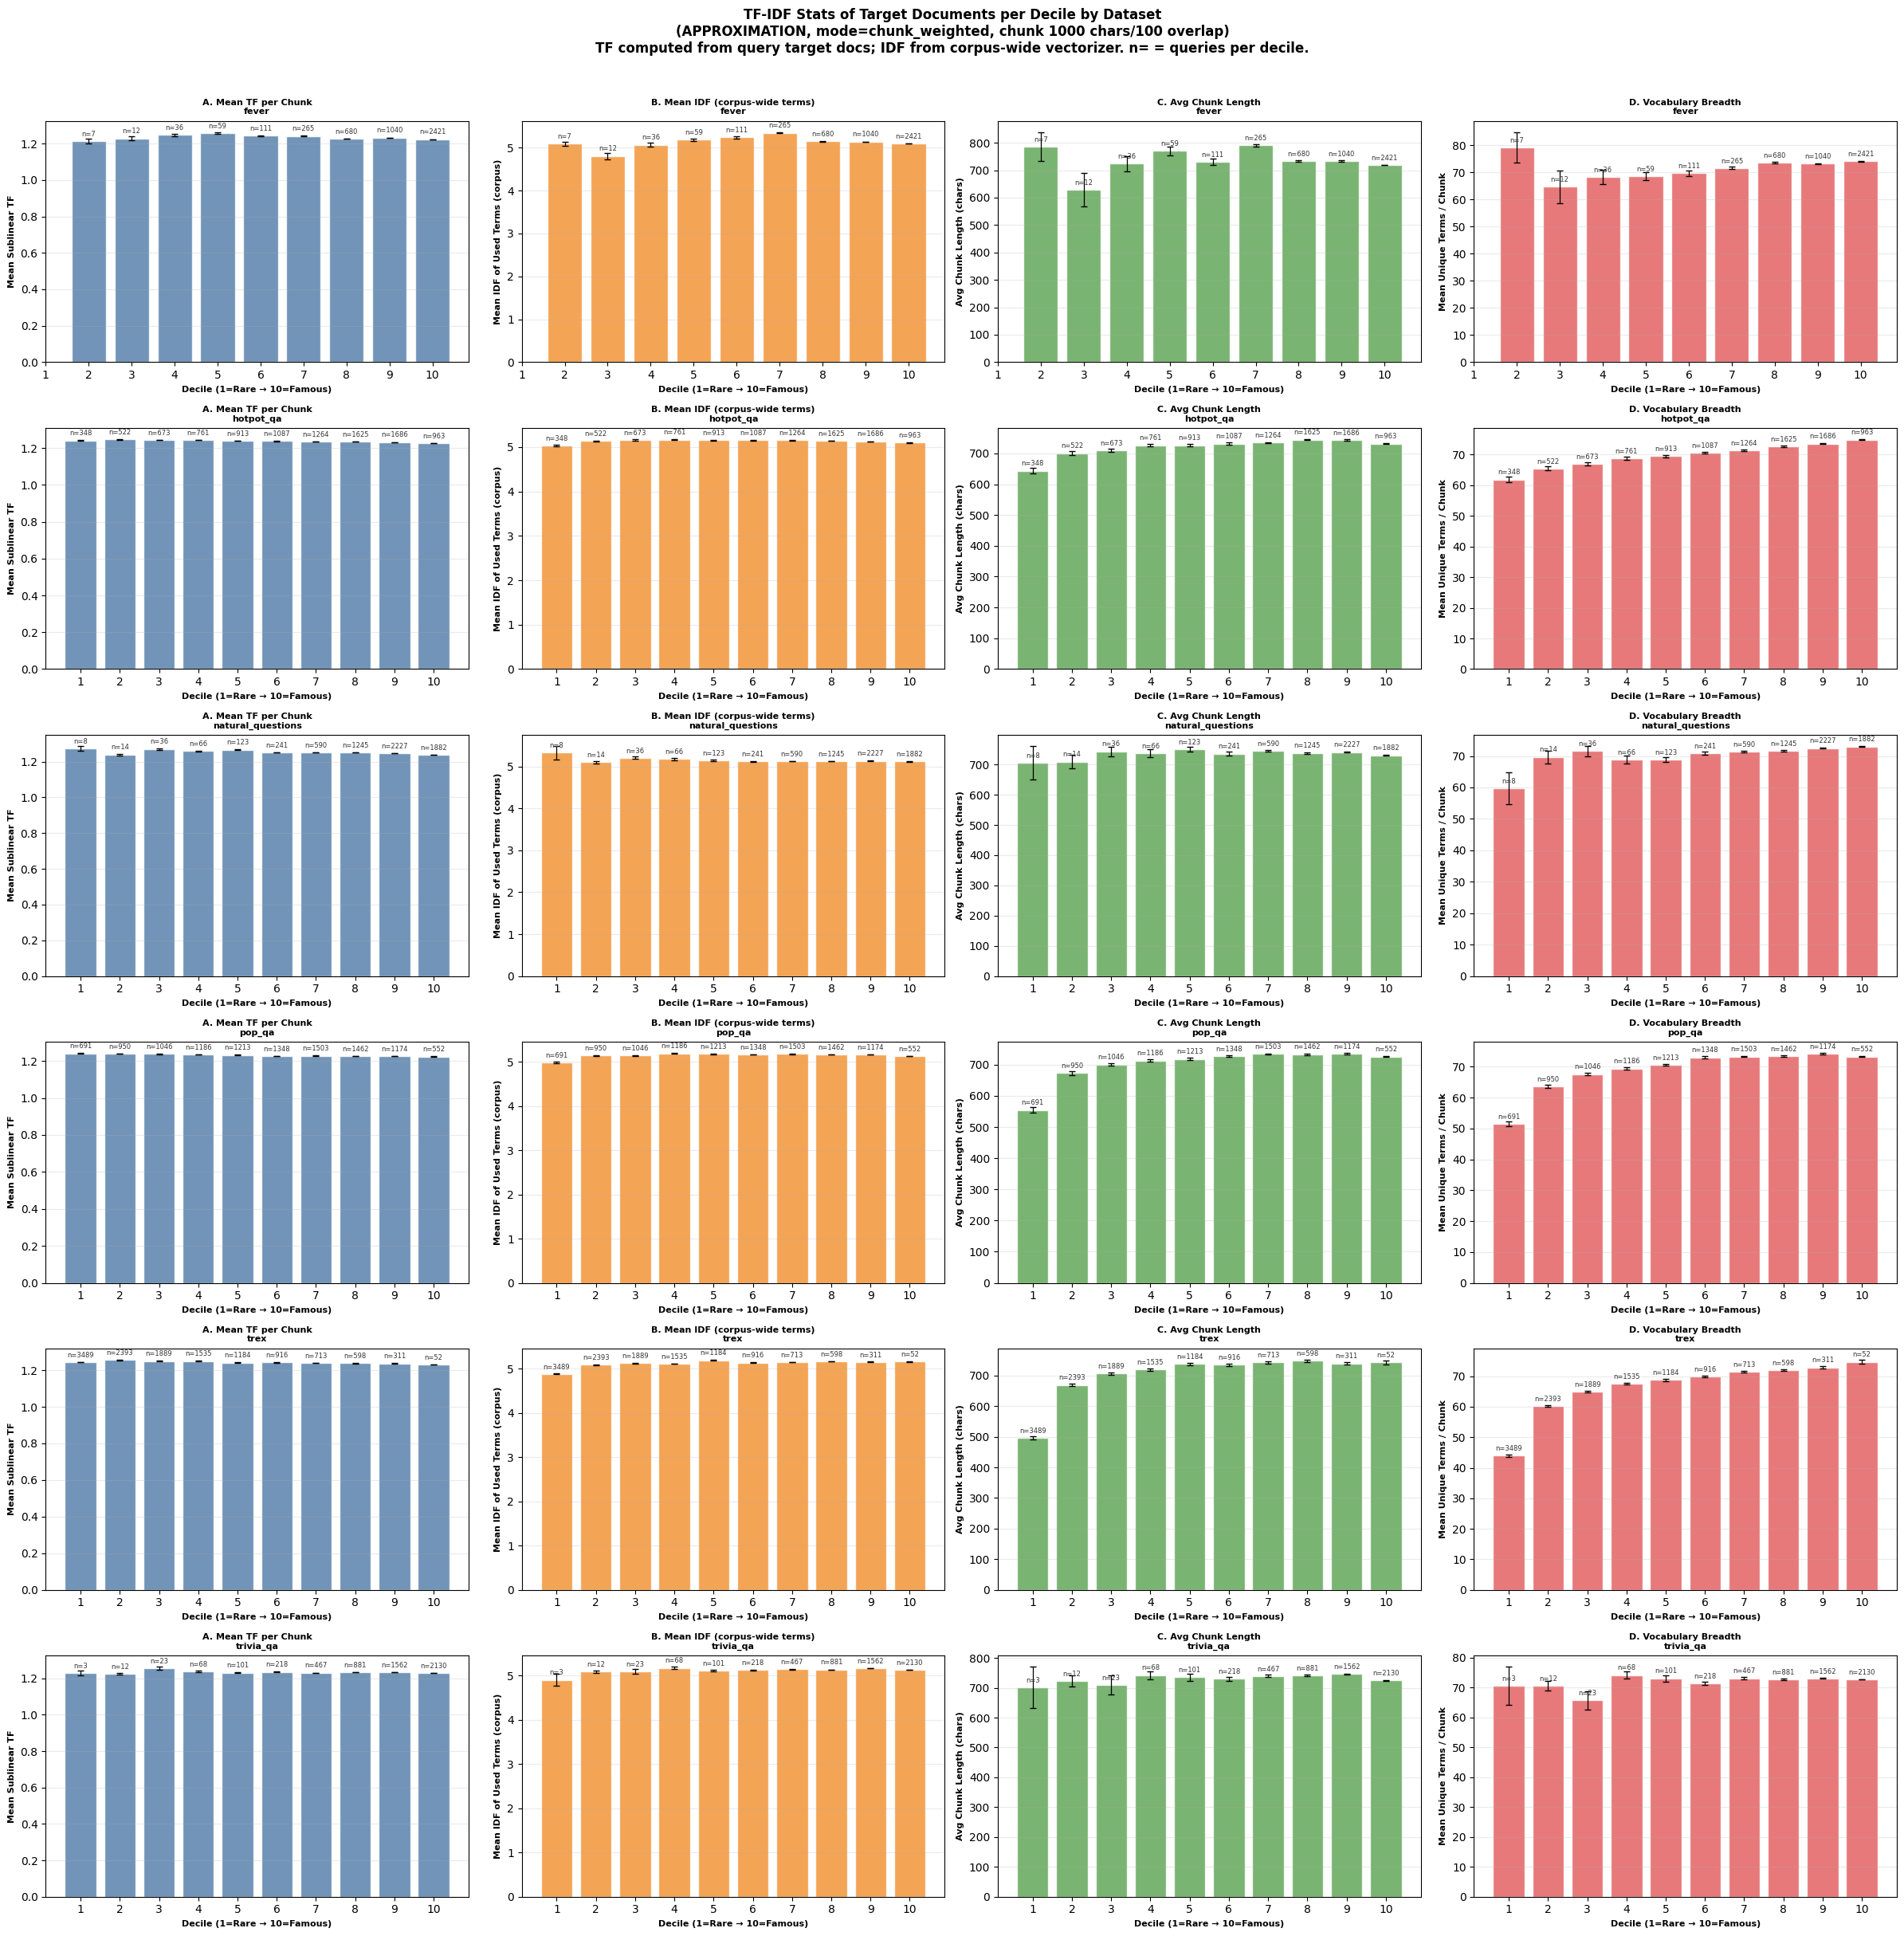

Saved → tfidf_idf_chunk_vocab_per_dataset_approximation.png

Computing per-dataset TF-IDF stats for: BM25
  Fetching 44,857 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 44,857 / 44,857 IDs in corpus
  Transforming 721,907 texts with corpus vectorizer (vocab=50,000)…
  Vocabulary in use: 50,000 terms


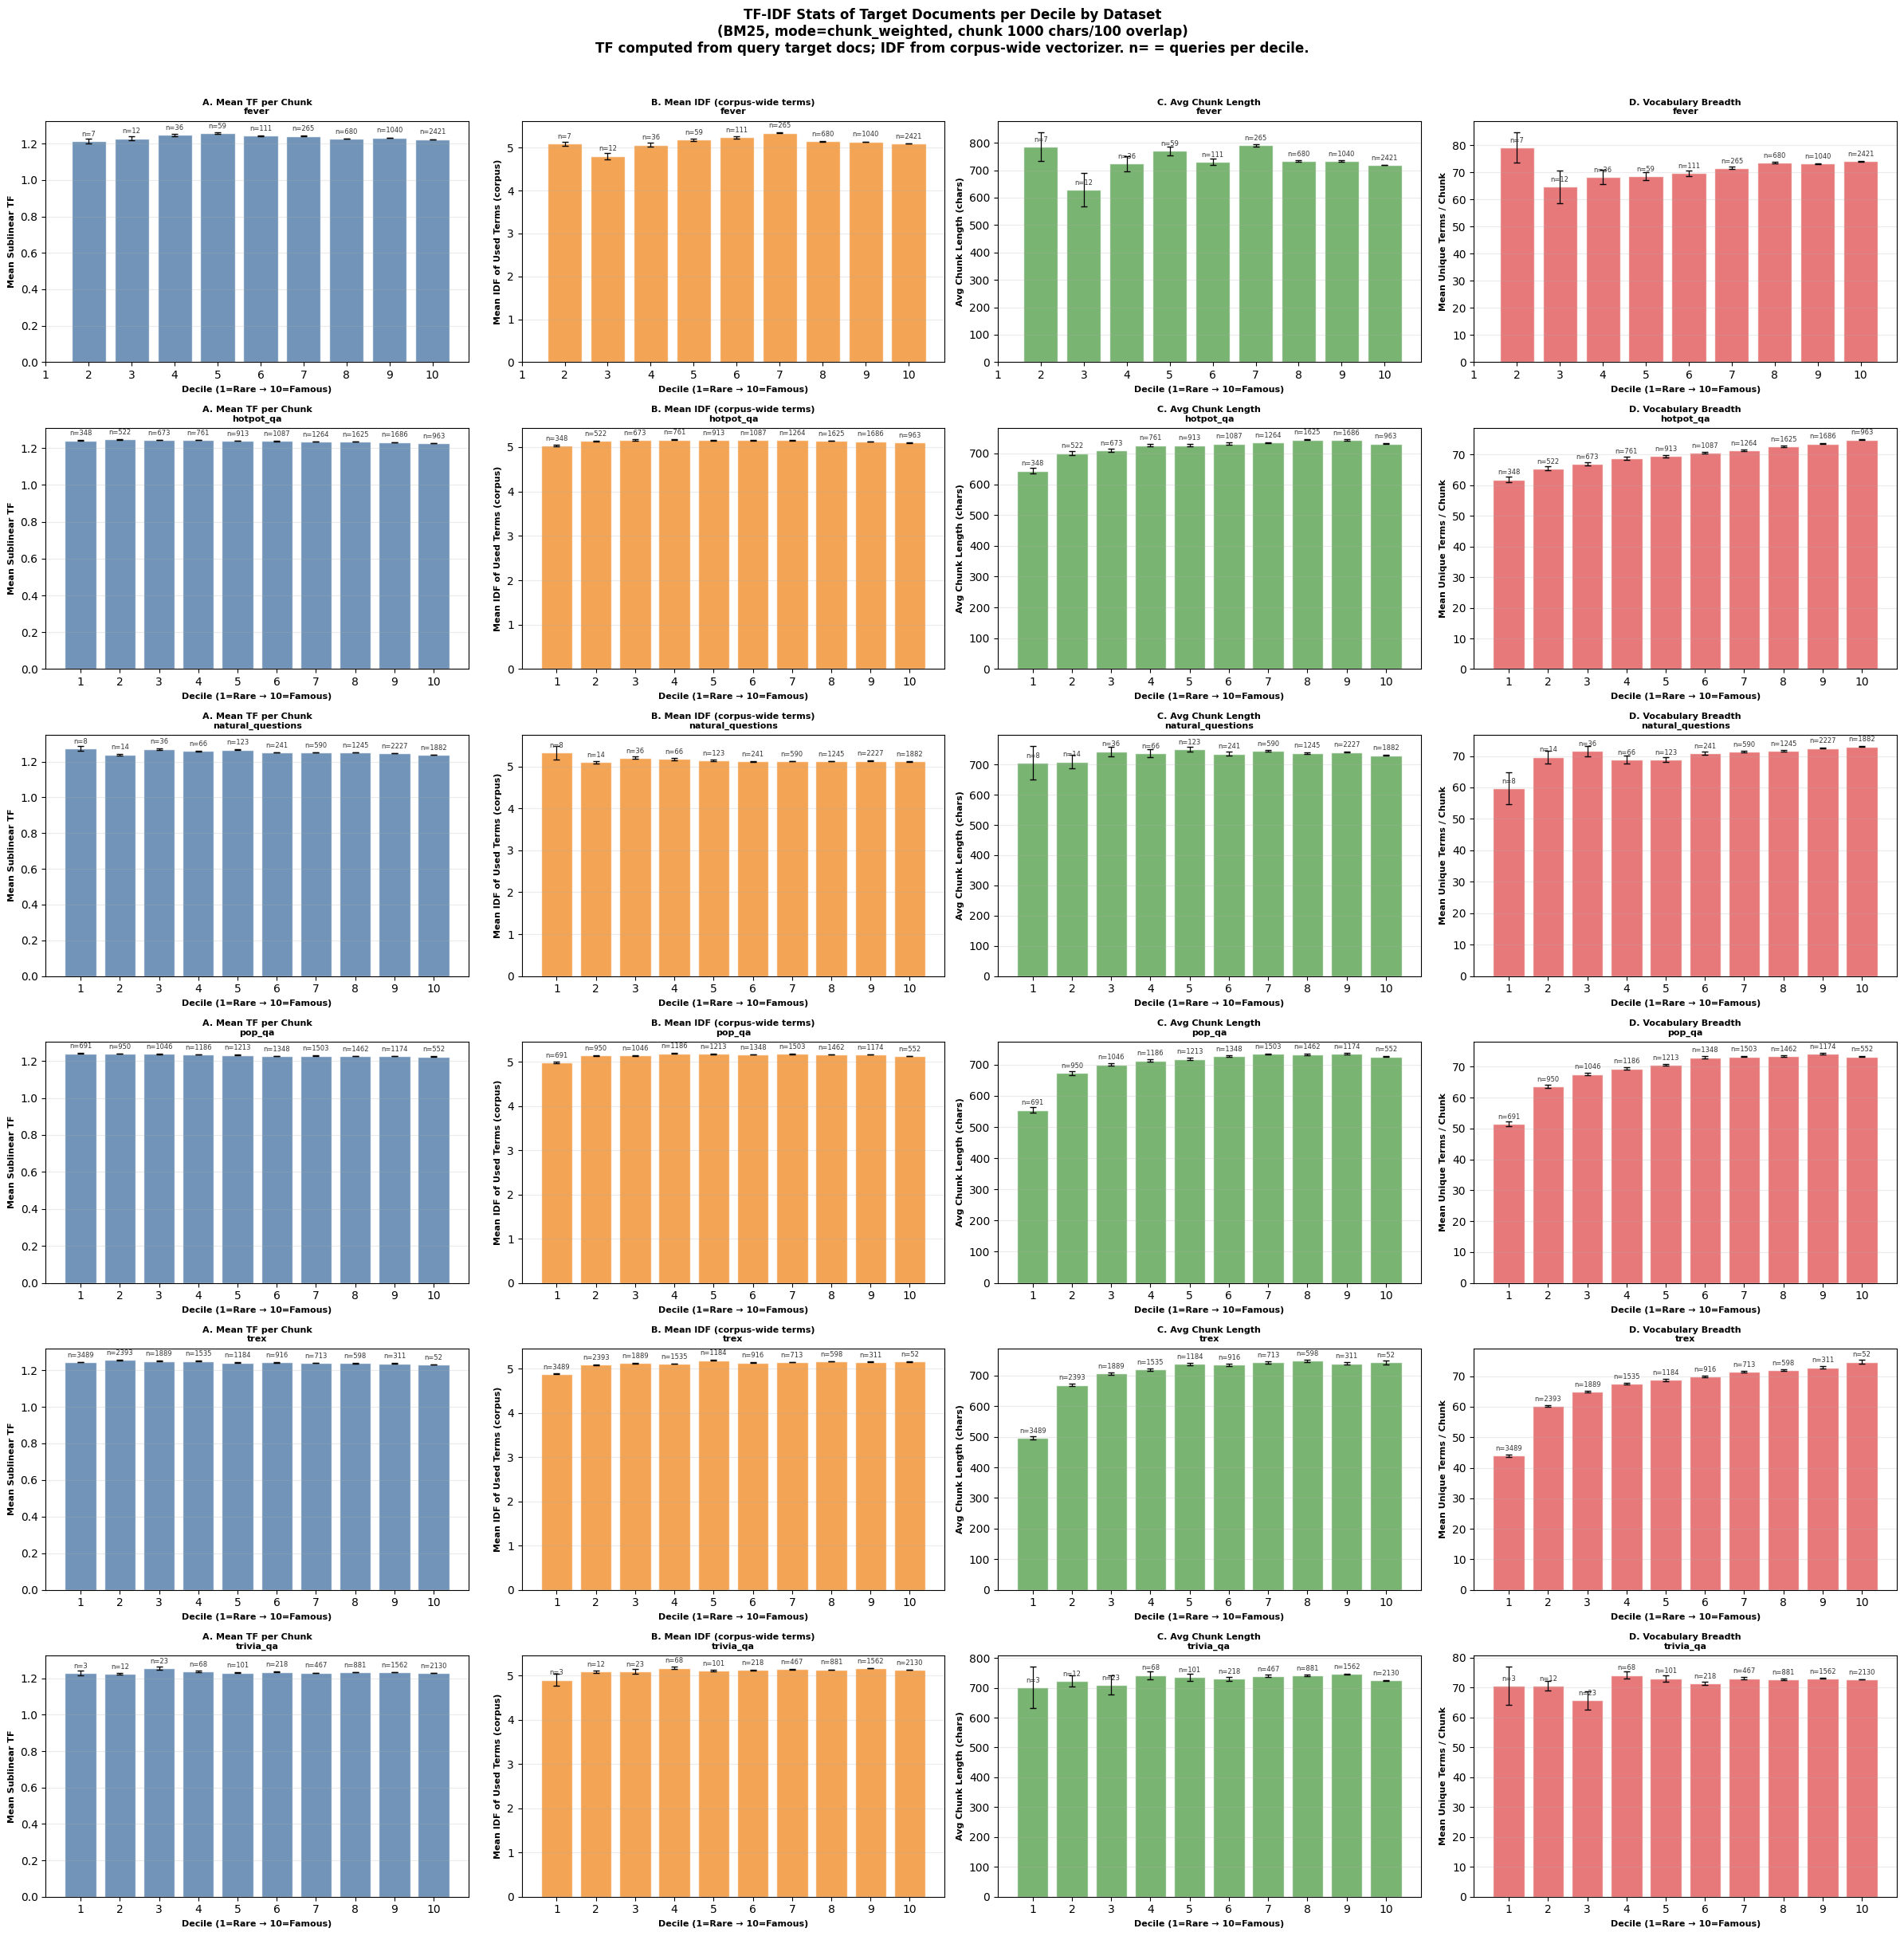

Saved → tfidf_idf_chunk_vocab_per_dataset_bm25.png


In [3]:
# ============================================================================
# 9b. TF-IDF / IDF / Chunk Length per Decile — per Dataset breakdown
# Uses corpus-wide IDF (from load_or_compute_corpus_vectorizer) so that
# term-specificity values are comparable across datasets and reflect true
# corpus rarity, not just rarity within each dataset's query target docs.
# ============================================================================

import importlib
import src.metrics.tfidf_service as _tfidf_mod
importlib.reload(_tfidf_mod)
from src.metrics.tfidf_service import (
    load_or_compute_corpus_vectorizer,
    compute_tfidf_stats_for_ids,
)
from src.metrics.decile_utils import decile_col_for, boundaries_for

decile_col = decile_col_for(DECILE_MODE)
d_idx = list(range(1, 11))

CHUNK_SIZE_9B    = 1000
CHUNK_OVERLAP_9B = 100
MAX_FEATURES_9B  = 50_000
SAMPLE_9B        = 20_000   # docs/decile for corpus vectorizer


def _pick_group_col(df):
    for candidate in ["company", "provider", "dataset_company", "dataset_source",
                       "dataset_name", "dataset", "qa_dataset", "source_dataset"]:
        if candidate in df.columns:
            return candidate
    return ""


# ── Load (or build+cache) the corpus-wide vectorizer once ────────────────────
print("Loading corpus-wide TF-IDF vectorizer…")
boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)
corpus_vec = load_or_compute_corpus_vectorizer(
    metadata_path=metadata_path,
    corpus_path=CORPUS_PATH,
    boundaries=boundaries,
    sample_per_decile=SAMPLE_9B,
    max_features=MAX_FEATURES_9B,
    chunk_size=CHUNK_SIZE_9B,
    chunk_overlap=CHUNK_OVERLAP_9B,
)

PANEL_CFG = [
    ("mean_tf_score",          "Mean Sublinear TF",              "A. Mean TF per Chunk",           "#4e79a7"),
    ("mean_idf_of_used_terms", "Mean IDF of Used Terms (corpus)", "B. Mean IDF (corpus-wide terms)", "#f28e2b"),
    ("mean_chunk_length",      "Avg Chunk Length (chars)",        "C. Avg Chunk Length",             "#59a14f"),
    ("mean_unique_terms",      "Mean Unique Terms / Chunk",       "D. Vocabulary Breadth",           "#e15759"),
]

for strategy in STRATEGIES:
    if strategy not in results_by_strategy:
        continue
    df = results_by_strategy[strategy]
    group_col = _pick_group_col(df)
    if not group_col:
        print(f"\u26a0 No dataset/company column found for {strategy} \u2014 skipping 9b")
        continue

    print(f"\n{'='*60}")
    print(f"Computing per-dataset TF-IDF stats for: {strategy.upper()}")
    print(f"{'='*60}")

    # Compute TF (from query target docs) with corpus-wide IDF
    per_group_stats = compute_tfidf_stats_for_ids(
        query_df=df[["wikipedia_id", decile_col, group_col]],
        corpus_path=CORPUS_PATH,
        decile_col=decile_col,
        group_col=group_col,
        corpus_vectorizer=corpus_vec,
        chunk_size=CHUNK_SIZE_9B,
        chunk_overlap=CHUNK_OVERLAP_9B,
    )

    datasets = sorted(per_group_stats.keys())
    n_ds = len(datasets)
    if n_ds == 0:
        print(f"  No data returned for {strategy}")
        continue

    fig, axes = plt.subplots(
        n_ds, 4,
        figsize=(24, 4 * n_ds),
        squeeze=False,
    )

    for row_idx, ds in enumerate(datasets):
        ds_stats = per_group_stats[ds]   # dict: decile_int -> stats_dict
        sub = df[df[group_col].astype(str) == ds]
        q_counts = [int((sub[decile_col] == d).sum()) for d in range(10)]

        for col_idx, (stat_key, ylabel, panel_label, color) in enumerate(PANEL_CFG):
            ax = axes[row_idx, col_idx]

            vals = [
                ds_stats[d].get(stat_key, float("nan")) if d in ds_stats else float("nan")
                for d in range(10)
            ]
            se_map = {
                "mean_tf_score":          "se_tf_score",
                "mean_idf_of_used_terms": "se_idf_of_used_terms",
                "mean_chunk_length":      "se_chunk_length",
                "mean_unique_terms":      "se_unique_terms",
            }
            err_key = se_map.get(stat_key)
            errs = (
                [ds_stats[d].get(err_key, 0.0) if d in ds_stats else 0.0 for d in range(10)]
                if err_key else None
            )

            ax.bar(d_idx, vals, color=color, alpha=0.80, edgecolor="white", linewidth=1)
            if errs is not None:
                ax.errorbar(d_idx, vals, yerr=errs,
                            fmt="none", color="black", capsize=3,
                            linewidth=1.2, elinewidth=0.9)

            valid_vals = [v for v in vals if v == v]
            y_max = max(valid_vals) if valid_vals else 1.0
            for xi, v, qc in zip(d_idx, vals, q_counts):
                if qc > 0:
                    label_y = (v if v == v else 0.0) + y_max * 0.015
                    ax.text(xi, label_y, f"n={qc}",
                            ha="center", va="bottom", fontsize=6, color="#333333")

            ax.set_xlabel("Decile (1=Rare \u2192 10=Famous)", fontsize=8, fontweight="bold")
            ax.set_ylabel(ylabel, fontsize=8, fontweight="bold")
            ax.set_title(f"{panel_label}\n{ds}", fontsize=8, fontweight="bold")
            ax.set_xticks(d_idx)
            ax.grid(axis="y", alpha=0.25)

    fig.suptitle(
        f"TF-IDF Stats of Target Documents per Decile by Dataset\n"
        f"({strategy.upper()}, mode={DECILE_MODE}, chunk {CHUNK_SIZE_9B} chars/{CHUNK_OVERLAP_9B} overlap)\n"
        "TF computed from query target docs; IDF from corpus-wide vectorizer. n= = queries per decile.",
        fontsize=12, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    out = RESULTS_DIR / f"tfidf_idf_chunk_vocab_per_dataset_{strategy}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved \u2192 {out.name}")


  Fetching 44,857 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 44,857 / 44,857 IDs in corpus
  Transforming 721,907 texts with corpus vectorizer (vocab=50,000)…
  Vocabulary in use: 50,000 terms


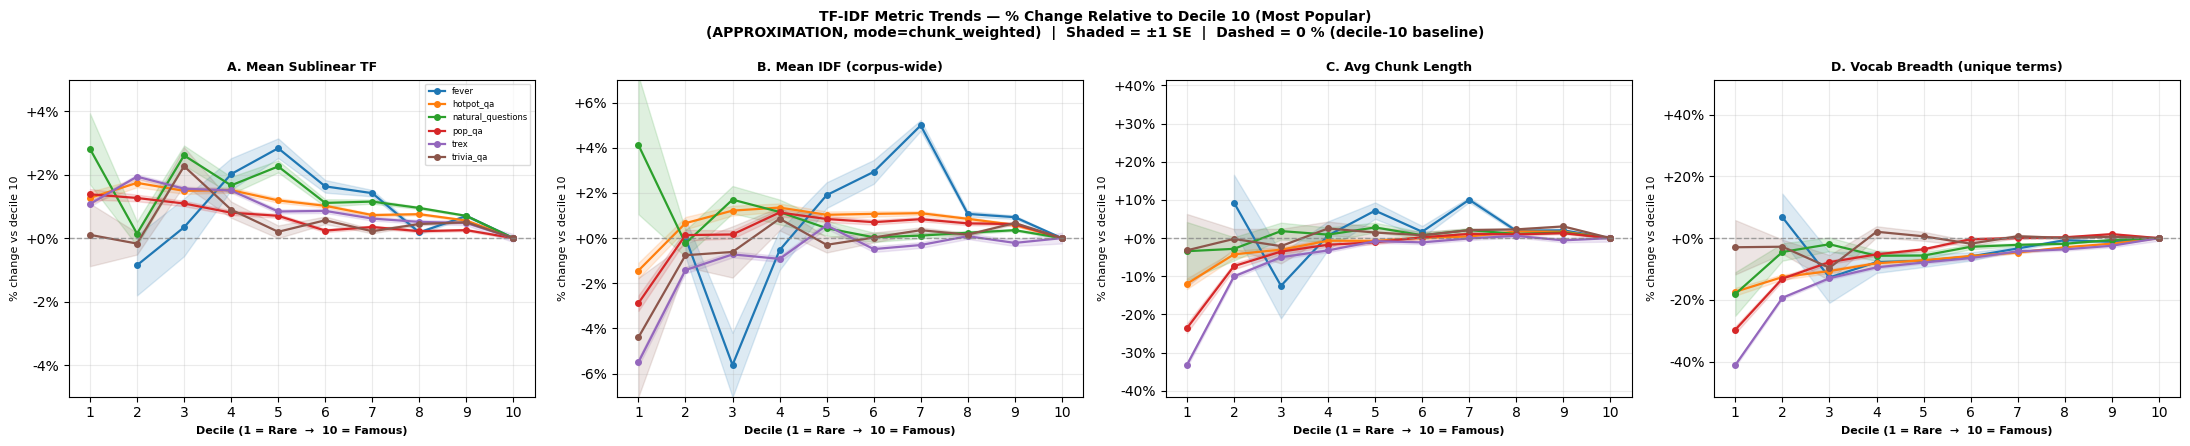

Saved → tfidf_trend_pct_vs_mean_approximation.png
  Fetching 44,857 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 44,857 / 44,857 IDs in corpus
  Transforming 721,907 texts with corpus vectorizer (vocab=50,000)…
  Vocabulary in use: 50,000 terms


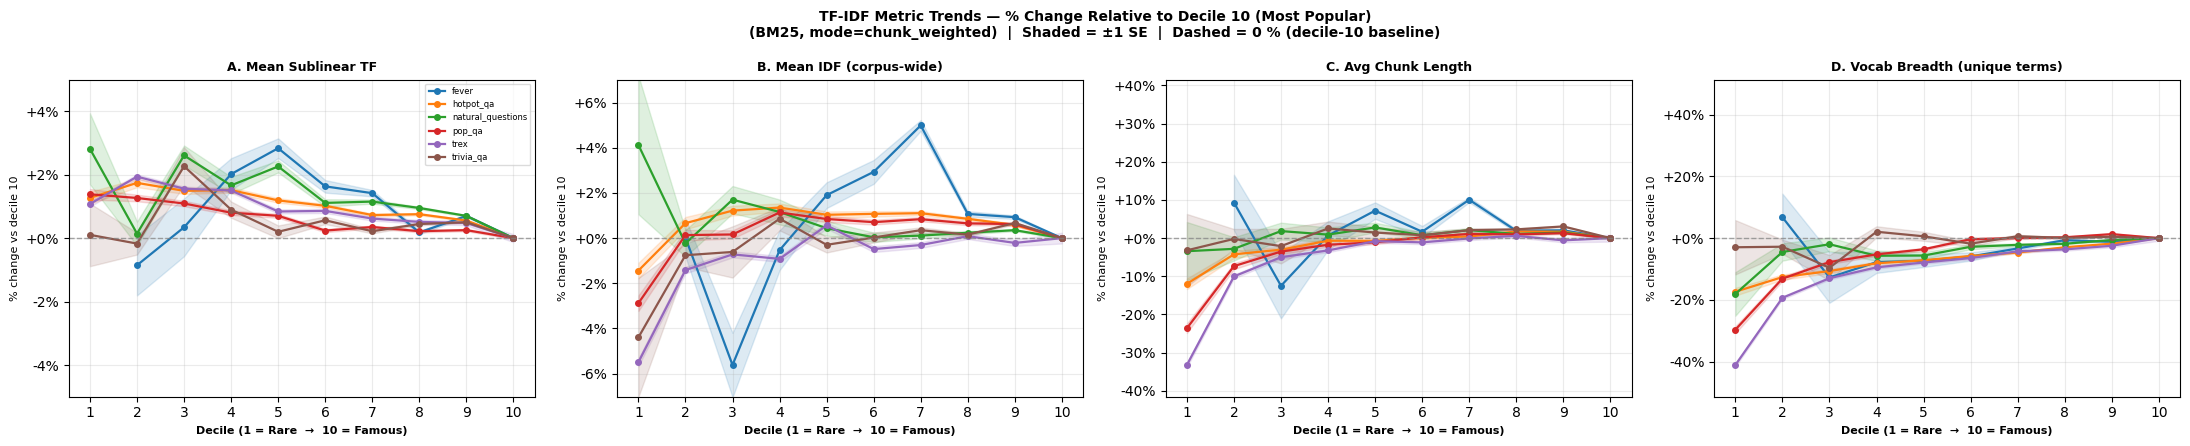

Saved → tfidf_trend_pct_vs_mean_bm25.png


In [4]:
# ============================================================================
# 9b000003. TF-IDF Trend — % Change vs Grand-Mean Baseline (per Dataset)
# Baseline = mean of the metric across all 10 deciles (= 0 %).
# Each decile is shown as % deviation from that grand mean.
#
# Error bands use full propagated uncertainty:
#   combined_se_d = sqrt(se_d² + se_mean²)
#   pct_err_d     = combined_se_d / |baseline| * 100
# where se_mean = sqrt(sum(se_i²)) / 10  (SE of the grand mean).
# This automatically widens bands for data-sparse deciles whose SE is large.
# ============================================================================

import numpy as _np

d_idx = list(range(1, 11))

TREND_PANELS = [
    ("mean_tf_score",          "se_tf_score",          "% change vs grand mean",  "A. Mean Sublinear TF",          "#4e79a7"),
    ("mean_idf_of_used_terms", "se_idf_of_used_terms", "% change vs grand mean",  "B. Mean IDF (corpus-wide)",     "#f28e2b"),
    ("mean_chunk_length",      "se_chunk_length",      "% change vs grand mean",  "C. Avg Chunk Length",           "#59a14f"),
    ("mean_unique_terms",      "se_unique_terms",      "% change vs grand mean",  "D. Vocab Breadth (unique terms)","#e15759"),
]

for strategy in STRATEGIES:
    if strategy not in results_by_strategy:
        continue
    df = results_by_strategy[strategy]
    group_col = _pick_group_col(df)
    if not group_col:
        continue

    # Always recompute — uses cached parquet so it is fast after the first run.
    _pgs = compute_tfidf_stats_for_ids(
        query_df=df[["wikipedia_id", decile_col, group_col]],
        corpus_path=CORPUS_PATH,
        decile_col=decile_col,
        group_col=group_col,
        corpus_vectorizer=corpus_vec,
        chunk_size=CHUNK_SIZE_9B,
        chunk_overlap=CHUNK_OVERLAP_9B,
    )

    datasets = sorted(_pgs.keys())
    if not datasets:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), squeeze=True)
    cmap = plt.get_cmap("tab10")

    for col_idx, (stat_key, se_key, ylabel, panel_label, _color) in enumerate(TREND_PANELS):
        ax = axes[col_idx]
        all_pct = []   # collect to set a tight common y-range per panel

        for ds_idx, ds in enumerate(datasets):
            ds_stats = _pgs[ds]
            color = cmap(ds_idx % 10)

            # Raw values and SE for deciles 0..9 (0-indexed internally)
            vals = _np.array(
                [ds_stats[d].get(stat_key, _np.nan) if d in ds_stats else _np.nan
                 for d in range(10)],
                dtype=float,
            )
            errs = _np.array(
                [ds_stats[d].get(se_key, 0.0) if d in ds_stats else 0.0
                 for d in range(10)],
                dtype=float,
            )

            # Baseline = grand mean across all available deciles
            finite_mask = _np.isfinite(vals)
            if finite_mask.sum() == 0:
                continue
            baseline = float(_np.nanmean(vals))
            if baseline == 0.0:
                continue

            # SE of the grand mean: propagate all per-decile SEs
            # se_mean = sqrt(sum(se_i^2)) / n_deciles
            n_dec = float(finite_mask.sum())
            se_mean = float(_np.sqrt(_np.nansum(errs ** 2))) / n_dec

            # % deviation from grand mean
            pct = (vals - baseline) / abs(baseline) * 100.0

            # Combined uncertainty: sqrt(se_d^2 + se_mean^2) / |baseline| * 100
            pct_err = _np.sqrt(errs ** 2 + se_mean ** 2) / abs(baseline) * 100.0

            all_pct.extend(pct[_np.isfinite(pct)].tolist())

            ax.plot(d_idx, pct, marker="o", markersize=4,
                    linewidth=1.6, color=color, label=ds)
            ax.fill_between(
                d_idx,
                pct - pct_err,
                pct + pct_err,
                alpha=0.15, color=color,
            )

        ax.axhline(0.0, color="grey", linewidth=1.0, linestyle="--", alpha=0.7)

        # Tight y-limits: ±(max absolute deviation + band) + 20 % headroom, min ±5 %
        if all_pct:
            margin = max(abs(_np.nanmax(all_pct)), abs(_np.nanmin(all_pct))) * 1.25
            margin = max(margin, 5.0)
            ax.set_ylim(-margin, margin)

        ax.set_xlabel("Decile (1 = Rare  →  10 = Famous)", fontsize=8, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_title(panel_label, fontsize=9, fontweight="bold")
        ax.set_xticks(d_idx)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
        ax.grid(alpha=0.25)
        if col_idx == 0:
            ax.legend(fontsize=6, loc="best", framealpha=0.7)

    fig.suptitle(
        f"TF-IDF Metric Trends — % Change Relative to Grand Mean (all deciles)\n"
        f"({strategy.upper()}, mode={DECILE_MODE})  |  Shaded = ±1 SE (propagated)  |  Dashed = 0 % (grand-mean baseline)",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()
    out = RESULTS_DIR / f"tfidf_trend_pct_vs_mean_{strategy}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved \u2192 {out.name}")


### TF-IDF, IDF & Avg Chunk Length per *Query* Decile

Cross-maps the **corpus-level** TF-IDF statistics (computed by `tfidf_service`) onto the
**query distribution** across deciles.  Each bar shows how many queries land in that decile
and the corresponding corpus-level vocabulary metrics — giving intuition for whether the
queries that target a particular popularity tier also target term-rich / specific vocabulary.

| Panel | Metric |
|---|---|
| A | Mean sublinear TF per corpus chunk |
| B | Mean IDF of used terms (term specificity) |
| C | Avg chunk character length |

Query counts are annotated above each bar.

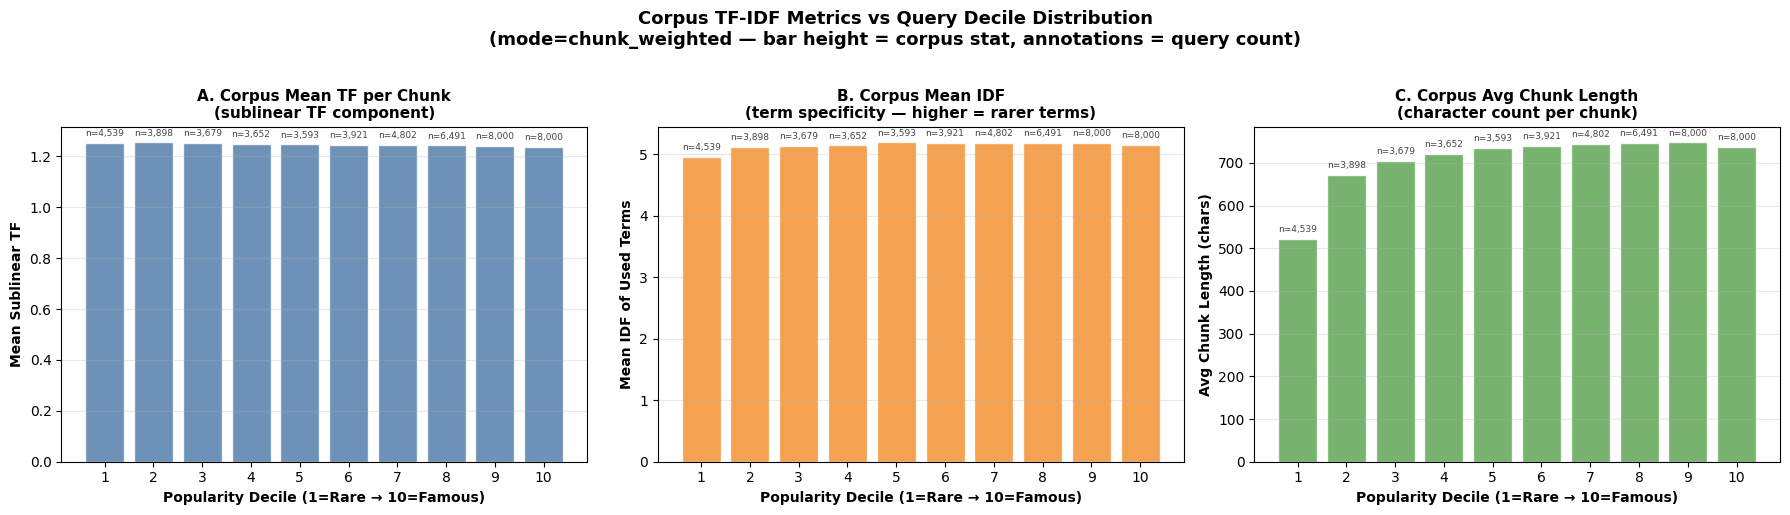

Saved → tfidf_idf_chunk_per_query_decile.png


In [5]:
# ============================================================================
# TF-IDF, IDF & Avg Chunk Length per Query Decile  (corpus-level stats overlay)
# ============================================================================

from src.metrics.decile_utils import decile_col_for

decile_col = decile_col_for(DECILE_MODE)

# Pull corpus-level stats into arrays indexed by decile (0-based)
_tf_vals       = [tfidf_stats.get(str(d), {}).get("mean_tf_score",          float("nan")) for d in range(10)]
_idf_vals      = [tfidf_stats.get(str(d), {}).get("mean_idf_of_used_terms", float("nan")) for d in range(10)]
_chunk_len_vals= [tfidf_stats.get(str(d), {}).get("mean_chunk_length",      float("nan")) for d in range(10)]

# Aggregate query counts per decile (across all strategies, use first available)
_ref_strategy = next(iter(results_by_strategy))
_df_ref = results_by_strategy[_ref_strategy]
_q_counts = [int((_df_ref[decile_col] == d).sum()) for d in range(10)]

d_idx = list(range(1, 11))
bar_color = ["#4e79a7", "#f28e2b", "#59a14f"]
panel_data = [
    (_tf_vals,        "Mean Sublinear TF",         "A. Corpus Mean TF per Chunk\n(sublinear TF component)",        bar_color[0]),
    (_idf_vals,       "Mean IDF of Used Terms",     "B. Corpus Mean IDF\n(term specificity — higher = rarer terms)", bar_color[1]),
    (_chunk_len_vals, "Avg Chunk Length (chars)",   "C. Corpus Avg Chunk Length\n(character count per chunk)",      bar_color[2]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (vals, ylabel, title, color) in zip(axes, panel_data):
    bars = ax.bar(d_idx, vals, color=color, alpha=0.82, edgecolor="white", linewidth=1)
    # Annotate query count above each bar
    y_max = max(v for v in vals if v == v)  # ignore nan
    for xi, v, qc in zip(d_idx, vals, _q_counts):
        if v == v:  # not nan
            ax.text(xi, v + y_max * 0.015, f"n={qc:,}",
                    ha="center", va="bottom", fontsize=6.5, color="#444444")
    ax.set_xlabel("Popularity Decile (1=Rare → 10=Famous)", fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(d_idx)
    ax.grid(axis="y", alpha=0.28)

fig.suptitle(
    f"Corpus TF-IDF Metrics vs Query Decile Distribution\n"
    f"(mode={DECILE_MODE} — bar height = corpus stat, annotations = query count)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
out = RESULTS_DIR / "tfidf_idf_chunk_per_query_decile.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out.name}")


## Retrieval Difficulty per Decile

Shows **why popular deciles are intrinsically easier** to retrieve from, independent of model quality:

| Panel | What it shows |
|---|---|
| A | Absolute corpus documents & chunks per decile |
| B | Gold QA questions per decile |
| C | Random-baseline hit probability = 1 / corpus_docs[d] |

A retriever picking chunks at random already has a much higher chance of returning the gold document in popular deciles, simply because those deciles contain far fewer unique documents.

✓ Saved → /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k/retrieval_difficulty_per_decile.png


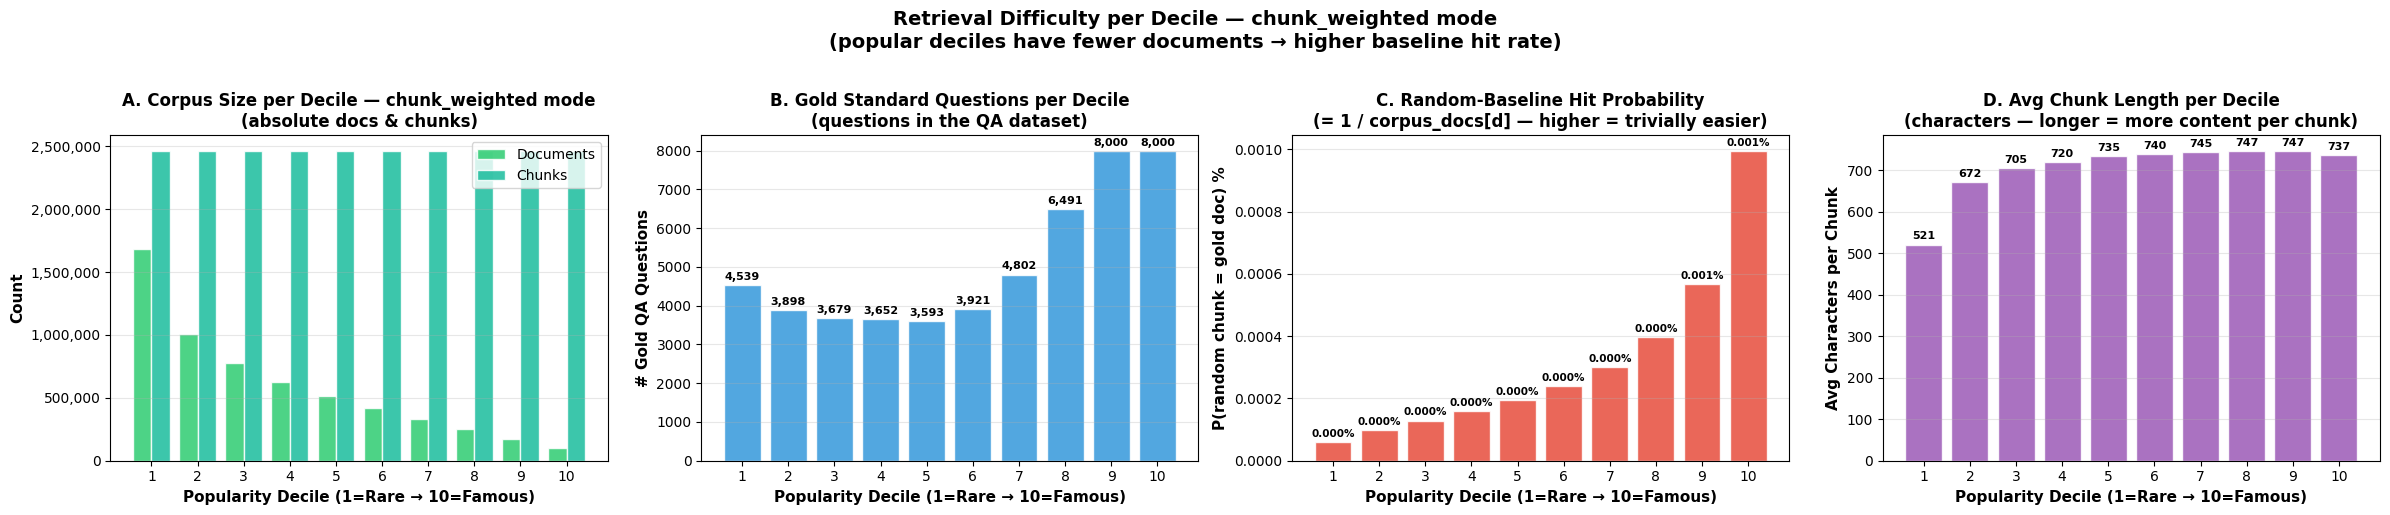

In [6]:
import importlib
import src.metrics.tfidf_service as _tfidf_mod
importlib.reload(_tfidf_mod)
from src.metrics.tfidf_service import plot_retrieval_difficulty

results_df = results_by_strategy[ALL_STRATEGIES[0]]

fig = plot_retrieval_difficulty(
    corpus_docs=corpus_docs,
    corpus_chunks=corpus_chunks,
    questions_per_decile=np.array([results_df[decile_col].value_counts().get(d, 0) for d in range(10)], dtype=float),
    tfidf_stats=tfidf_stats,
    decile_mode=DECILE_MODE,
    out_path=RESULTS_DIR / "retrieval_difficulty_per_decile.png",
)
plt.show()